In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils2 import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils2 import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [8]:
def train_model(X, Y, rf=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=1000, eval_metric="rmse"
        )
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        if df_paths.shape[1] == 1:
            cand_pe = position_encoder(df_paths, type="onehot")
        else:
            cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime_action)
    df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)

    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)

    rewards_matrix = preds_action[:, 1:]
    rewards_matrix = np.hstack([rewards_matrix,preds_value])

    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    best_idx = np.argmax(total_disc)

    return int(df_paths.iloc[best_idx, 1]), df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma,normalization=True)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    return pregret,preds


def softmax(x, tau=1.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    z = (x - np.max(x)) / tau   # numerical stability
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

def choose_next_state_softmax(
    rf_action,
    rf_value,
    current_state,
    t_now,
    t_prime_action,
    t_prime_value,
    gamma,
    tau=1.0,
    rng=None
):
    """Sample next state using softmax exploration over discounted returns."""
    if rng is None:
        rng = np.random.default_rng()

    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime_action)
    df_paths_value = np.asarray(df_paths.iloc[:, -1]).reshape(-1, 1)

    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now + t_prime_action, t_prime_value)

    rewards_matrix = preds_action[:, 1:]
    rewards_matrix = np.hstack([rewards_matrix, preds_value])

    discounts = gamma ** np.arange(0, t_prime_action + 1)   # assumes total columns = t_prime_action + 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    probs = softmax(total_disc, tau=tau)
    chosen_idx = np.random.choice(len(total_disc), p=probs)

    return int(df_paths.iloc[chosen_idx, 1]), df_paths, rewards_matrix, probs, total_disc


In [69]:
T = 200
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 100
PREGRETS = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards

    rf_value = train_model(X_train, Y_train_value)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    for delta_t in range(1,DELTA_T+1):
        tau = max(0.0001, 2.0 * (0.8 ** delta_t))
        next_state, df_paths, preds, probs, total_disc = choose_next_state_softmax(
        rf_action,
        rf_value,
        current_state,
        T + delta_t,
        t_prime_action,
        t_prime_value,
        gamma,
        tau=tau,
        rng=515+rep)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        ## PolicyIteration
        X_train = np.vstack([X_train, next_features])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = T+delta_t,normalization = False)
 
        rf_value = train_model(X_train, Y_train_value)
        
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val,pred = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)


(200,)
rep 0, T_train 201, pregret=0.2700
rep 0, T_train 202, pregret=0.0245
rep 0, T_train 203, pregret=0.0244
rep 0, T_train 204, pregret=0.0000
rep 0, T_train 205, pregret=0.0000
rep 0, T_train 206, pregret=0.0000
rep 0, T_train 207, pregret=0.0000
rep 0, T_train 208, pregret=0.0000
rep 0, T_train 209, pregret=0.0053
rep 0, T_train 210, pregret=0.0000
rep 0, T_train 211, pregret=0.0227
rep 0, T_train 212, pregret=0.0276
rep 0, T_train 213, pregret=0.0224
rep 0, T_train 214, pregret=0.0360
rep 0, T_train 215, pregret=0.0310
rep 0, T_train 216, pregret=0.0448
rep 0, T_train 217, pregret=0.0410
rep 0, T_train 218, pregret=0.0439
rep 0, T_train 219, pregret=0.0293
rep 0, T_train 220, pregret=0.0048
rep 0, T_train 221, pregret=0.0000
rep 0, T_train 222, pregret=0.0000
rep 0, T_train 223, pregret=0.0000
rep 0, T_train 224, pregret=0.0000
rep 0, T_train 225, pregret=0.0048
rep 0, T_train 226, pregret=0.0048
rep 0, T_train 227, pregret=0.0047
rep 0, T_train 228, pregret=0.0047
rep 0, T_trai

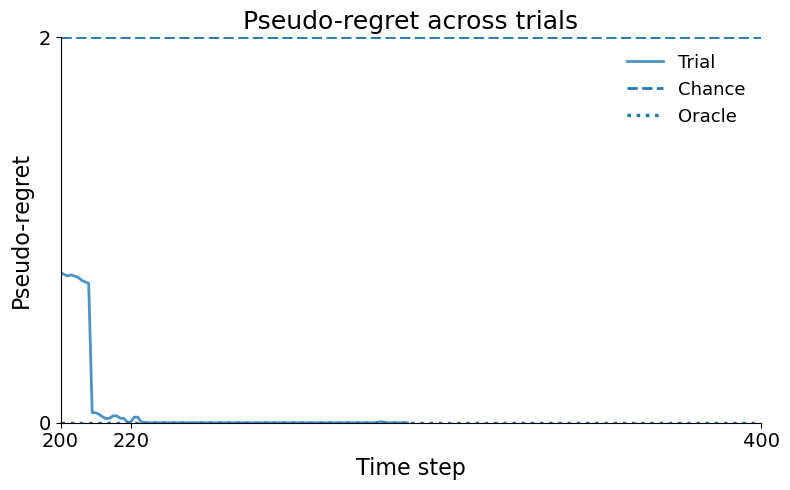

In [ ]:
# PREGRETS shape: (10, 200)
# x-axis should run from 200 to 399
x = np.arange(200, 300)

# ---- set these to your actual baselines ----
chance_perf = 2.0
oracle_perf = 0.0
# -------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# plot all 10 raw trials
for i in range(10):
    ax.plot(x, PREGRETS[i], linewidth=2, alpha=0.8, label="Trial" if i == 0 else None)

# chance and oracle reference lines
ax.axhline(chance_perf, linestyle="--", linewidth=2, label="Chance")
ax.axhline(oracle_perf, linestyle=":", linewidth=2.5, label="Oracle")

# labels with units
ax.set_xlabel("Time step", fontsize=16)
ax.set_ylabel("Pseudo-regret", fontsize=16)
ax.set_title("Pseudo-regret across trials", fontsize=18)

# show min/max numbers on axes
ymin = min(np.min(PREGRETS), chance_perf, oracle_perf)
ymax = max(np.max(PREGRETS), chance_perf, oracle_perf)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(ymin, ymax)

ax.set_xticks([200,220,400])
ax.set_yticks([ymin, ymax])

# tight axes: no extra padding
ax.margins(x=0, y=0)

# make fonts legible
ax.tick_params(axis='both', labelsize=14)

# cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=13, frameon=False)
plt.tight_layout()
plt.show()

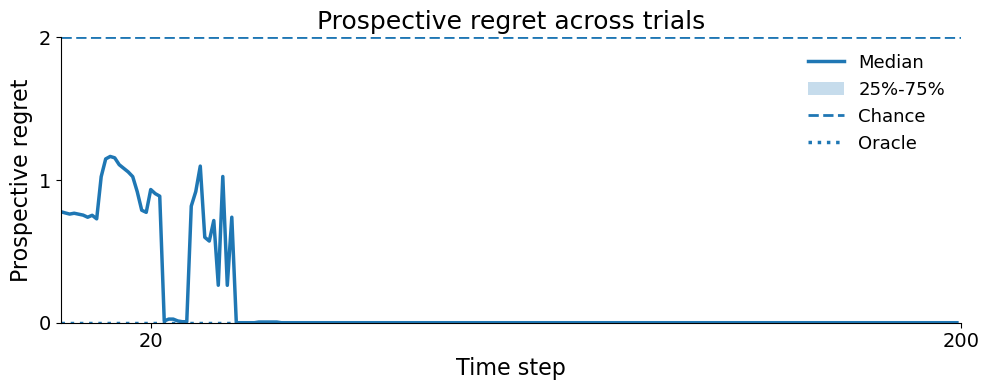

In [38]:
# make sure it is a numpy array
PREGRETS_arr = np.asarray(PREGRETS)

# x-axis: 200 to 399
x = np.arange(200, 400)-200

# baselines
chance_perf = 2.0
oracle_perf = 0.0

# summary statistics across reps
pregrets_median = np.median(PREGRETS_arr, axis=0)
pregrets_q25 = np.percentile(PREGRETS_arr, 25, axis=0)
pregrets_q75 = np.percentile(PREGRETS_arr, 75, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))

# median and IQR
ax.plot(x, pregrets_median, linewidth=2.5, label="Median")
ax.fill_between(x, pregrets_q25, pregrets_q75, alpha=0.25, label="25%-75%")

# chance and oracle
ax.axhline(chance_perf, linestyle="--", linewidth=2, label="Chance")
ax.axhline(oracle_perf, linestyle=":", linewidth=2.5, label="Oracle")

# labels
ax.set_xlabel("Time step", fontsize=16)
ax.set_ylabel("Prospective regret", fontsize=16)
ax.set_title("Prospective regret across trials", fontsize=18)

# tight axes
ymin = min(np.min(pregrets_q25), chance_perf, oracle_perf)
ymax = max(np.max(pregrets_q75), chance_perf, oracle_perf)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(ymin, ymax)
ax.set_xticks([20,200])
ax.set_yticks([0,1,2])
ax.margins(x=0, y=0)

# styling
ax.tick_params(axis='both', labelsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=13, frameon=False)

plt.tight_layout()
plt.savefig("pregrets_plot.png", dpi=300, bbox_inches="tight")
# np.save("pregrets.npy", PREGRETS_arr)
plt.show()

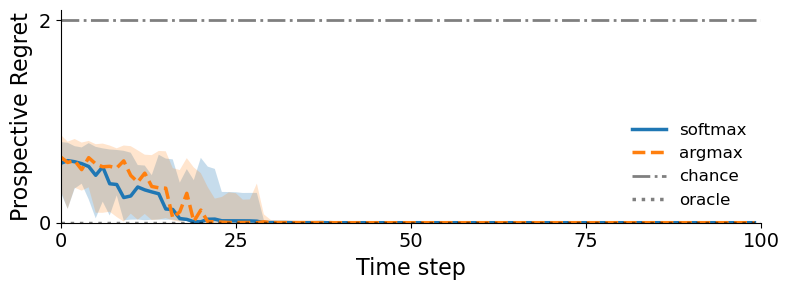

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- load both datasets ----------
# softmax_data = np.load("/Users/yuxinbai/Desktop/projects_repo/ProspectiveForging/results/exploration/softmax_10reps.npz")
argmax_data  = np.load("/Users/yuxinbai/Desktop/projects_repo/ProspectiveForging/results/exploration/argmax_10reps.npz")

# PREGRETS_softmax = softmax_data['pregrets_online'][:,:100]
PREGRETS_softmax = np.asarray(PREGRETS)
PREGRETS_argmax = argmax_data['pregrets_online'][:,:100]

# x-axis
x = np.arange(200, 300)-200

# baselines
chance_perf = 2.0
oracle_perf = 0.0

# ---------- compute statistics ----------
softmax_median = np.median(PREGRETS_softmax, axis=0)
softmax_q25 = np.percentile(PREGRETS_softmax, 25, axis=0)
softmax_q75 = np.percentile(PREGRETS_softmax, 75, axis=0)

argmax_median = np.median(PREGRETS_argmax, axis=0)
argmax_q25 = np.percentile(PREGRETS_argmax, 25, axis=0)
argmax_q75 = np.percentile(PREGRETS_argmax, 75, axis=0)

fig, ax = plt.subplots(figsize=(8,3))

# ---------- softmax ----------
ax.plot(x, softmax_median, linewidth=2.5, label="softmax")
ax.fill_between(x, softmax_q25, softmax_q75, alpha=0.25)

# ---------- argmax ----------
ax.plot(x, argmax_median, linewidth=2.5, linestyle="--", label="argmax")
ax.fill_between(x, argmax_q25, argmax_q75, alpha=0.20)

# ---------- baselines ----------
ax.axhline(chance_perf, linestyle="dashdot", linewidth=2, label="chance",color = 'k',alpha = 0.5)
ax.axhline(oracle_perf, linestyle=":", linewidth=2.5, label="oracle",color = 'k',alpha = 0.5)

# labels
ax.set_xlabel("Time step", fontsize=16)
ax.set_ylabel("Prospective Regret", fontsize=16)

# axis limits
ymin = min(np.min(softmax_q25), np.min(argmax_q25), chance_perf, oracle_perf)
ymax = max(np.max(softmax_q75), np.max(argmax_q75), chance_perf, oracle_perf)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(ymin, ymax+0.1)

ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks([ymin, ymax])
ax.margins(x=0, y=0)

ax.tick_params(axis='both', labelsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
# plt.savefig("softmax_vs_argmax_regret.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
PREGRETS_softmax

NpzFile '/Users/yuxinbai/Desktop/projects_repo/ProspectiveForging/results/exploration/softmax_10reps.npz' with keys: pregrets_online

In [158]:
T = 200
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 400
PREGRETS_random = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards

    rf_value = train_model(X_train, Y_train_value)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t, t_prime_action, t_prime_value, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        ## PolicyIteration

        X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        Y_train_action = irewards[:T+delta_t]

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, gamma,T = T+delta_t,normalization = False)
        is_pos = (Y_train_value > threshold).astype(int)
        pos = is_pos.sum()
        neg = len(Y_train_value) - pos
        w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value, sample_weight=w)
        
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val,pred = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS_random.append(PREGRET)


(200,)
(201, 57) (201,) (201,)
rep 0, T_train 201, pregret=0.0246
(202, 57) (202,) (202,)
rep 0, T_train 202, pregret=0.2693
(203, 57) (203,) (203,)
rep 0, T_train 203, pregret=0.0244
(204, 57) (204,) (204,)
rep 0, T_train 204, pregret=0.0243
(205, 57) (205,) (205,)
rep 0, T_train 205, pregret=0.0242
(206, 57) (206,) (206,)
rep 0, T_train 206, pregret=0.0240
(207, 57) (207,) (207,)
rep 0, T_train 207, pregret=0.0239
(208, 57) (208,) (208,)
rep 0, T_train 208, pregret=0.0237
(209, 57) (209,) (209,)
rep 0, T_train 209, pregret=0.0235
(210, 57) (210,) (210,)
rep 0, T_train 210, pregret=0.2652
(211, 57) (211,) (211,)
rep 0, T_train 211, pregret=0.0277
(212, 57) (212,) (212,)
rep 0, T_train 212, pregret=0.0228
(213, 57) (213,) (213,)
rep 0, T_train 213, pregret=0.0271
(214, 57) (214,) (214,)
rep 0, T_train 214, pregret=0.0222
(215, 57) (215,) (215,)
rep 0, T_train 215, pregret=0.0218
(216, 57) (216,) (216,)
rep 0, T_train 216, pregret=0.0355
(217, 57) (217,) (217,)
rep 0, T_train 217, pregr

In [25]:
PREGRETS_arr = np.vstack(PREGRETS)
# PREGRETS_random_arr = np.vstack(PREGRETS_random)
np.savez(
    f"../results/exploration/softmax_10reps.npz",
    pregrets_online = PREGRETS_arr,
    # pregrets_offline = PREGRETS_random_arr
    )
    

